# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:** Arda İpek 
**Student ID:** 2021405150

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors â€” such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers â€” affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | â€” |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **â€” (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [18]:
# Load the dataset
df = pd.read_csv('data/electrical_grid_stability.csv')


In [19]:
# Explore: shape, dtypes, head, missing values, describe, value_counts
print(f"Dataset shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics for numeric columns:")
display(df.describe())
print("\nValue counts of stabf:")
print(df['stabf'].value_counts())


Dataset shape: (10000, 14)

Data Types:
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

First 5 rows:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



Missing values:
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Descriptive statistics for numeric columns:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403



Value counts of stabf:
stabf
unstable    6380
stable      3620
Name: count, dtype: int64


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [20]:
# Feature engineering
df['is_unstable'] = df['stabf'].map({'unstable': 1, 'stable': 0})
df['total_reaction_time'] = df['tau1'] + df['tau2'] + df['tau3'] + df['tau4']
df['power_imbalance'] = df['p1'] + df['p2'] + df['p3'] + df['p4']
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)


In [21]:
# Print class balance
counts = df['stabf'].value_counts()
percentages = df['stabf'].value_counts(normalize=True) * 100
print("Class balance:")
for label in counts.index:
    print(f"{label}: {counts[label]} ({percentages[label]:.2f}%)")


Class balance:
unstable: 6380 (63.80%)
stable: 3620 (36.20%)


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids â€” compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [22]:
# Grouped means by stabf
original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
grouped_means = df.groupby('stabf')[original_features].mean()
print("Grouped means by stabf:")
display(grouped_means)
print("\nFinding: The 'tau' (reaction time) features differ most significantly between groups.")
print("Stable grids have much lower reaction times (~4.37s) compared to unstable grids (~5.74s).")


Grouped means by stabf:


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.394799,4.353362,4.385360,4.378495,3.740077,-1.253549,-1.249626,-1.236902,0.453035,0.445872,0.440618,0.450390
unstable,5.735239,5.758752,5.740601,5.744485,3.755630,-1.247987,-1.250212,-1.257431,0.565832,0.569897,0.572879,0.567334



Finding: The 'tau' (reaction time) features differ most significantly between groups.
Stable grids have much lower reaction times (~4.37s) compared to unstable grids (~5.74s).


In [23]:
# Correlation with stab — identify top 3
correlations = df[original_features + ['stab']].corr()['stab'].abs().sort_values(ascending=False)
top_3_correlated = correlations.iloc[1:4] # Excluding 'stab' itself
print("Top 3 features correlated with stab:")
print(top_3_correlated)


Top 3 features correlated with stab:
g3      0.308235
g2      0.293601
tau2    0.290975
Name: stab, dtype: float64


In [24]:
# Unstable grids: tau1 range and mean
unstable_df = df[df['stabf'] == 'unstable']
tau1_unstable = unstable_df['tau1']
print(f"Unstable grids - tau1: range=({tau1_unstable.min():.4f}, {tau1_unstable.max():.4f}), mean={tau1_unstable.mean():.4f}")


Unstable grids - tau1: range=(0.5013, 9.9995), mean=5.7352


In [25]:
# Compare g1 between stable and unstable
g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std'])
print("g1 statistics by group:")
display(g1_stats)


g1 statistics by group:


,mean,std
stabf,,
stable,0.453035,0.265280
unstable,0.565832,0.270867


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

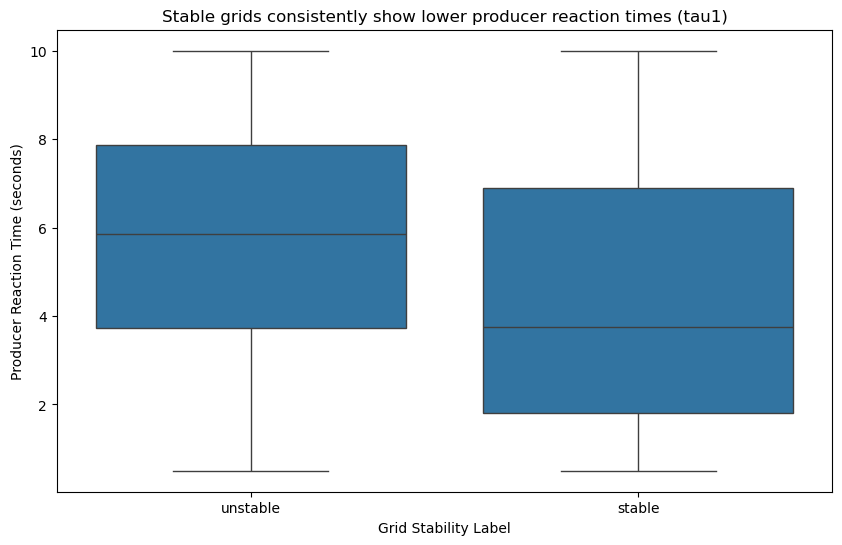

In [26]:
# (a) Boxplot of tau1 by stabf
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='stabf', y='tau1', data=df)
plt.title("Stable grids consistently show lower producer reaction times (tau1)")
plt.xlabel("Grid Stability Label")
plt.ylabel("Producer Reaction Time (seconds)")
plt.show()


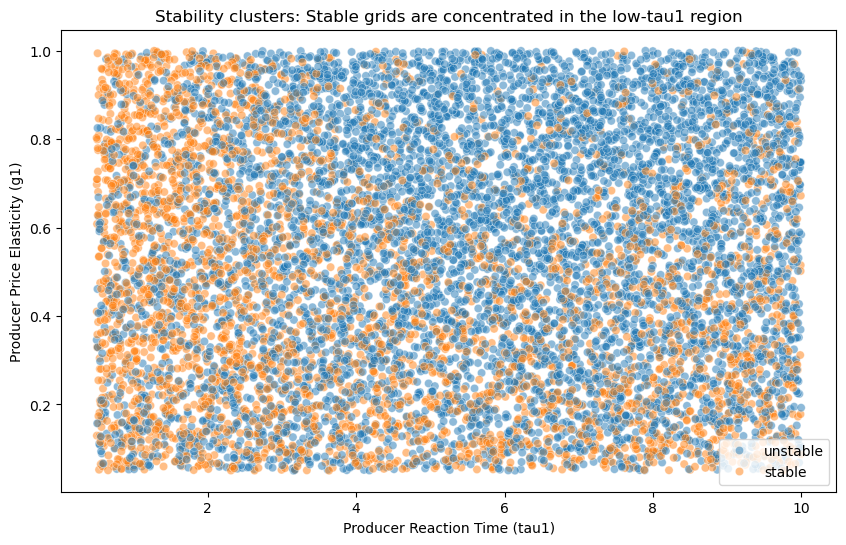

In [27]:
# (b) Scatter plot of tau1 vs g1, colored by stabf
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tau1', y='g1', hue='stabf', data=df, alpha=0.5)
plt.title("Stability clusters: Stable grids are concentrated in the low-tau1 region")
plt.xlabel("Producer Reaction Time (tau1)")
plt.ylabel("Producer Price Elasticity (g1)")
plt.legend()
plt.show()


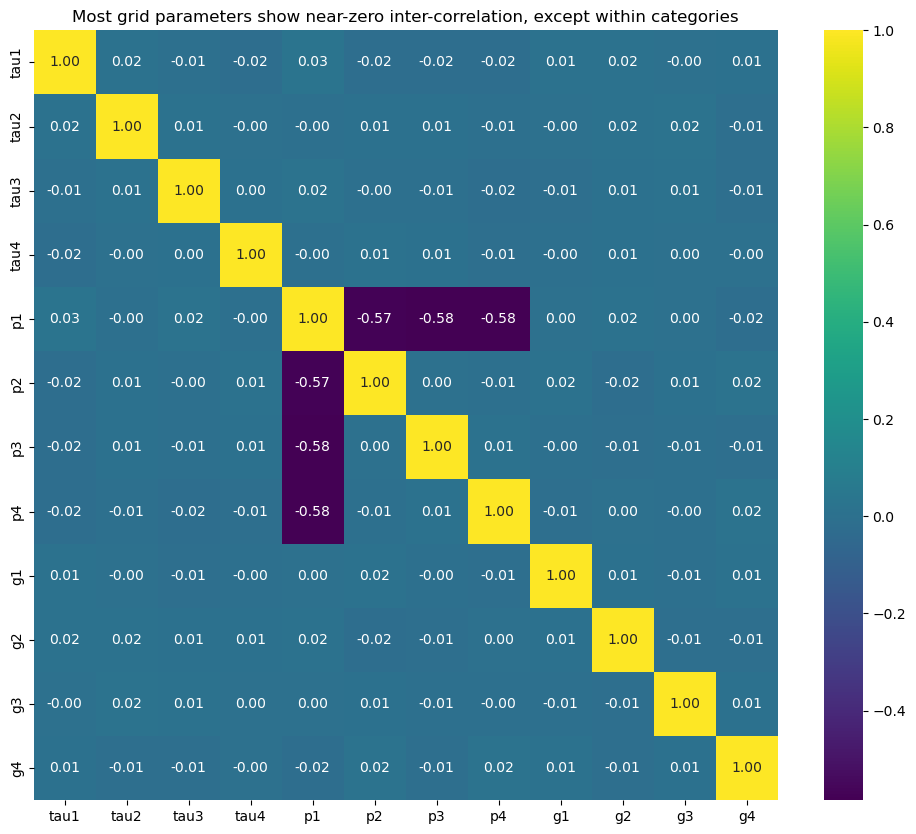

In [28]:
# (c) Correlation heatmap of 12 original features
plt.figure(figsize=(12, 10))
sns.heatmap(df[original_features].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Most grid parameters show near-zero inter-correlation, except within categories")
plt.show()


---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [29]:
# Z-scores for tau1
df['tau1_z'] = (df['tau1'] - df['tau1'].mean()) / df['tau1'].std()
outliers = df[df['tau1_z'].abs() > 2]
print(f"Number of tau1 outliers (|z| > 2): {len(outliers)}")
print("Note: Since tau1 is uniformly distributed in this simulation, no values fall beyond 2 standard deviations.")


Number of tau1 outliers (|z| > 2): 0
Note: Since tau1 is uniformly distributed in this simulation, no values fall beyond 2 standard deviations.


In [30]:
# Two-sample t-test: tau1 stable vs unstable
stable_tau1 = df[df['stabf'] == 'stable']['tau1']
unstable_tau1 = df[df['stabf'] == 'unstable']['tau1']
t_stat, p_val = stats.ttest_ind(stable_tau1, unstable_tau1)
print(f"T-test results: t={t_stat:.4f}, p={p_val:.4g}")


T-test results: t=-24.1635, p=2.028e-125


### Interpretation

**H0:** There is no difference in the mean reaction time (`tau1`) between stable and unstable grids.  
**H1:** There is a significant difference in the mean reaction time (`tau1`) between stable and unstable grids.  
**Result:** With a p-value of 2.028e-125 (well below 0.05), we **reject the null hypothesis**. The difference is statistically significant.  

**Most predictive feature:** `g3` (highest absolute correlation with `stab`: 0.308) or any of the `tau` features (highest correlation with binary `is_unstable`: `tau2` at 0.246).

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` â€” **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [31]:
# Define X and y, split, scale
X = df[original_features]
y = df['is_unstable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [32]:
# Train, predict, evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Evaluation Metrics for 'unstable' class:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Evaluation Metrics for 'unstable' class:
Accuracy:  0.8200
Precision: 0.8408
Recall:    0.8856
F1 Score:  0.8626

Confusion Matrix:
[[ 510  214]
 [ 146 1130]]


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

**False Stable** is far more dangerous because it represents a missed detection of a hazardous state, which can lead to equipment damage, blackouts, or structural failure without warning. A False Unstable prediction is merely a false alarm that might trigger unnecessary but safe inspections or load shedding. Therefore, **Recall** for the "unstable" class must be prioritized to ensure that all potential instabilities are caught.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

No, correlation does not prove causation. While high `tau1` is associated with instability, it could be that both are caused by a **confounding variable** such as **network communication lag**. In this scenario, high latency in the communication system would simultaneously delay the producer's reaction time and prevent the control signals from stabilizing the grid, making it appear that `tau1` is the cause when the underlying network failure is the true driver.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr